# STARE-PODS — Rendezvous Analytics

*Companion notebook for the video walkthrough. Everything runs live against
**AWS S3** (Parquet chunks) + **RDS Postgres** (the `PodsMetadata` catalog);
the granules were ingested beforehand, so this notebook only queries.*

**STARE-PODS** — the **STARE Parallel Optimized Data Store** — leverages the
STARE quad-tree hierarchy to partition and organize geospatial data, and thus
enables distributed parallel processing of native data without requiring
re-gridding, i.e. resampling and/or re-projection.

For this demo of the STARE-PODS prototype, swaths of level 1C data from four
microwave radiometers — GPM's **GMI**, DMSP's **SSMIS**, GCOM-W1's **AMSR2**,
and JPSS's **ATMS** — were decomposed at quad-furcation level four (**QL4**).
This results in 2048 pods, corresponding to 2048 QL4 STARE spherical
triangles, or *trixels*, each ~600+ km on a side, or an area of approximately
200,000 km². The decomposition extracts the data elements of each swath that
overlap a given QL4 trixel and packages them into a Parquet chunk file —
so a pod (a logical construct) contains data chunks from **all** the swaths
that overlap (non-empty intersect) with the pod area: a natural spatial
co-location.

During the decomposition, a database management system (PostgreSQL)
catalogues all necessary information to reconstitute the swath granule — the
chunk's granule and pod identities, its space-time extents, etc., as well as
the metadata of the original HDF/netCDF file. Because the database holds the
chunks' spatiotemporal information, it can serve as a cross-instrument
**rendezvous engine**.

1. **The temporal catalog** — every chunk knows *where* and *when*
2. **Rendezvous analytics** — who met whom
3. **Maps of rendezvous in swaths** — the coverage map
4. **Rendezvous up close** — the tightest pair, then all four
5. **Rendezvous over a region of interest** — space and time in one query


In [1]:
import logging
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from great_tables import loc, style
from great_tables import GT as _GT


def GT(frame, **kwargs):
    """great_tables.GT, house-styled: bold centered title, centered subtitle
    (inline styles, so the notebook viewer's own table CSS cannot override
    them), and plain-word column labels auto-capitalized — code identifiers
    such as t_start keep their spelling."""
    table = (_GT(frame, **kwargs)
             .tab_style(style=style.text(align='center', weight='bold'),
                        locations=loc.title())
             .tab_style(style=style.text(align='center'),
                        locations=loc.subtitle()))
    labels = {c: c[0].upper() + c[1:] for c in frame.columns
              if isinstance(c, str) and re.fullmatch(r'[a-z][a-z ]*', c)}
    if labels:
        table = table.cols_label(labels)
    return table

logging.getLogger('starepandas').setLevel(logging.WARNING)  # keep outputs clean

import starepandas
from starepandas.demo_lib import StarePodsDemo
from starepandas.staredataframe import parse_chunk_filename
from starepandas.io.granules import load_s3_metadata, load_s3_temporal_catalog
from starepandas.overlap import (
    rendezvous_events, overlap_matrix, overlap_pod_table, pod_drilldown,
    fold_instrument,
)
from starepandas.demo_plots import (
    chunk_pixels, plot_pod_coverage, plot_region_cover, plot_region_result,
    plot_rendezvous, pod_pixels, pod_trixels, rendezvous_examples,
)

CONFIG_PATH = os.path.join(
    os.path.dirname(os.path.abspath(starepandas.__file__)), ".config")
S3_PREFIX = "s3://zarrpods/gmi-demo-parquet"    # the demo's storage root
OVERLAP_DT = pd.Timedelta(minutes=45)           # coincidence window Δt
STARE_LEVEL = 4
INSTRUMENTS = ["GMI", "SSMIS", "AMSR2", "ATMS"]


def fmt_times(frame, columns=('t_start', 't_end')):
    """Render timestamp columns as compact strings for table display."""
    out = frame.copy()
    for column in columns:
        out[column] = out[column].dt.strftime('%Y-%m-%d %H:%M:%S')
    return out


demo = StarePodsDemo(aws_config_path=CONFIG_PATH)

# One thin load: podcode / Dataset / t_start / t_end — nothing else. The
# path_prefix scopes the shared RDS catalog to this demo's own storage root.
catalog = load_s3_temporal_catalog(path_prefix=S3_PREFIX)


## The data in the store

Six real granules, one calendar day — 2025-01-01. Four passive-microwave
radiometers on four different satellites, all at **Level 1C**: intercalibrated
brightness temperatures (`Tc`), on the GPM XCAL common calibration. Every fact
in the tables below is read straight back from the catalog — the chunk file
names preserve the original granule identity, e.g.

`1C.F18.SSMIS.XCAL2021-V.20250101-S112813-E131004.078441.V07B`

(level · platform · instrument · intercalibration · sensing window · orbit ·
product version).

In [2]:
# Full metadata for the demo's storage root (reused for the maps later); the
# stored chunk path ends in <podcode>-<granule file name>-<dataset>.parquet,
# so the library's own filename parser recovers each chunk's granule.
demo_meta = load_s3_metadata(path_prefix=S3_PREFIX)

info = pd.DataFrame({
    'granule': [parse_chunk_filename(path)[1] for path in demo_meta['group_path']],
    'dataset': demo_meta['Dataset'],
    'podcode': demo_meta['podcode'],
})
parts = info['granule'].str.split('.', expand=True)
info['level'], info['platform'], info['instrument'] = parts[0], parts[1], parts[2]
info['orbit'], info['version'] = parts[5], parts[6]

SATELLITES = {'GPM': 'GPM Core Observatory', 'F18': 'DMSP F18',
              'GCOMW1': 'GCOM-W1', 'NOAA21': 'NOAA-21 (JPSS-2)'}
L1C_CHANNELS = {'GMI': 13, 'SSMIS': 11, 'AMSR2': 12, 'ATMS': 9}

rows = []
for instrument in INSTRUMENTS:
    sub = info[info['instrument'] == instrument]
    groups = sorted(d.split('_', 1)[1] for d in sub['dataset'].unique())
    rows.append({
        'instrument': instrument,
        'satellite': SATELLITES.get(sub['platform'].iloc[0], sub['platform'].iloc[0]),
        'product': f"{sub['level'].iloc[0]}{instrument} {sub['version'].iloc[0]}",
        'channels': L1C_CHANNELS[instrument],
        'datasets': f"{len(groups)} ({groups[0]}–{groups[-1]})",
        'granules': sub['granule'].nunique(),
        'chunks': len(sub),
        'pods': sub['podcode'].nunique(),
    })
display(
    GT(pd.DataFrame(rows))
    .tab_header(title="What the decomposition put in the store",
                subtitle=f"{info['granule'].nunique()} granules → "
                         f"{info['dataset'].nunique()} datasets → "
                         f"{len(info)} chunks in {info['podcode'].nunique()} pods "
                         "— all Level 1C, 2025-01-01")
    .cols_label(product="L1C product", channels="L1C channels",
                datasets="Datasets (scan groups)")
    .tab_source_note("channel counts per the GPM V07 file specification; "
                     "a dataset = one scan group of one instrument")
)


GT(_tbl_data=  instrument             satellite       product  channels   datasets  \
0        GMI  GPM Core Observatory    1CGMI V07B        13  2 (S1–S2)   
1      SSMIS              DMSP F18  1CSSMIS V07B        11  4 (S1–S4)   
2      AMSR2               GCOM-W1  1CAMSR2 V07A        12  6 (S1–S6)   
3       ATMS      NOAA-21 (JPSS-2)   1CATMS V07A         9  2 (S1–S2)   

   granules  chunks  pods  
0         2    1020   509  
1         2    2988   672  
2         1    2145   359  
3         1    1003   502  , _body=<great_tables._gt_data.Body object at 0x15ea91730>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='satellite', type=<ColInfoTypeEnum.default: 1>, column_label='Satellite', column_align='left', column_width=None), ColInfo(var='product', type=<ColInfoTypeEnum.default: 1>, column_label='L1C product', column_align='left', column_width=None), ColInfo(var='channels', type=<ColInfoTypeEnum.default: 1>, column_label='L1C channels', column_align='right', column_width=None), ColInfo(var='datasets', type=<ColInfoTypeEnum.default: 1>, column_label='Datasets (scan groups)', column_align='left', column_width=None), ColInfo(var='granules', type=<ColInfoTypeEnum.default: 1>, column_label='Granules', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175e31b80>, _spanners=Spanners([]), _heading=Heading(title='What the decomposition put in the store', subtitle='6 granules → 14 datasets → 7156 chunks in 1220 pods — all Level 1C, 2025-01-01', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175e30110>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175e30140>, _source_notes=['channel counts per the GPM V07 file specification; a dataset = one scan group of one instrument'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175e30170>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table

## Part 1 — The temporal catalog

When a granule is decomposed, the database records the start and end times of
every chunk — `t_start` and `t_end`, the earliest and latest **scan times of
the data elements inside the chunk** — together with the chunk's spatial
address, the **pod code**: the chunk's STARE index written as a quaternary
(base-4) number. Like STARE indices, pod codes encode STARE's quad-tree
hierarchy — each digit refines the previous, similar to a postal code. The
scan times are actual times extracted from the granule's content, **not** the
time in the granule's file name.


In [3]:
per_ds = (catalog.groupby('Dataset', as_index=False)
          .agg(chunks=('podcode', 'size'),
               pods=('podcode', 'nunique'),
               first_start=('t_start', 'min'),
               last_end=('t_end', 'max')))
display(
    GT(fmt_times(per_ds, ('first_start', 'last_end')))
    .tab_header(title="The temporal catalog — one row per dataset",
                subtitle=f"{len(catalog)} chunks in {catalog['podcode'].nunique()} "
                         "pods, from one thin query")
    .cols_label(first_start="First t_start", last_end="Last t_end")
)
pod_chunks = catalog.groupby('podcode').size()
n_possible = 8 * 4 ** STARE_LEVEL            # 8 octants x 4^level trixels
busiest = pod_chunks.idxmax()
occupancy = pd.DataFrame([
    {'statistic': f'Level-{STARE_LEVEL} pods on the globe',
     'value': f'{n_possible}'},
    {'statistic': 'Pods holding at least one chunk',
     'value': f'{len(pod_chunks)} ({len(pod_chunks) / n_possible:.0%})'},
    {'statistic': 'Empty pods',
     'value': f'{n_possible - len(pod_chunks)}'},
    {'statistic': 'Fewest chunks in an occupied pod',
     'value': f'{pod_chunks.min()} (in {(pod_chunks == pod_chunks.min()).sum()} pods)'},
    {'statistic': 'Median chunks per occupied pod',
     'value': f'{pod_chunks.median():.0f}'},
    {'statistic': 'Most chunks in one pod',
     'value': f'{pod_chunks.max()} — pod {busiest}'},
])
display(
    GT(occupancy)
    .tab_header(title=f"Pod occupancy at level {STARE_LEVEL}",
                subtitle=f"how the {len(catalog)} chunks spread over the "
                         "QL4 decomposition")
    .cols_label(statistic="", value="")
)

display(
    GT(fmt_times(catalog.head(6)))
    .tab_header(title="Sample chunk rows",
                subtitle="where (podcode) and when (t_start, t_end) — "
                         "measured from the data, not the file name")
)


GT(_tbl_data=     Dataset  chunks  pods          first_start             last_end
0   AMSR2_S1     358   358  2025-01-01 20:19:15  2025-01-01 21:58:07
1   AMSR2_S2     357   357  2025-01-01 20:19:15  2025-01-01 21:58:07
2   AMSR2_S3     357   357  2025-01-01 20:19:15  2025-01-01 21:58:07
3   AMSR2_S4     358   358  2025-01-01 20:19:15  2025-01-01 21:58:07
4   AMSR2_S5     359   359  2025-01-01 20:19:15  2025-01-01 21:58:07
5   AMSR2_S6     356   356  2025-01-01 20:19:15  2025-01-01 21:58:07
6    ATMS_S1     502   502  2025-01-01 20:17:07  2025-01-01 21:58:35
7    ATMS_S2     501   501  2025-01-01 20:17:07  2025-01-01 21:58:35
8     GMI_S1     529   509  2025-01-01 11:29:53  2025-01-01 22:22:22
9     GMI_S2     491   471  2025-01-01 11:29:53  2025-01-01 22:22:22
10  SSMIS_S1     751   672  2025-01-01 11:28:14  2025-01-01 21:39:22
11  SSMIS_S2     750   670  2025-01-01 11:28:14  2025-01-01 21:39:22
12  SSMIS_S3     740   665  2025-01-01 11:28:14  2025-01-01 21:39:22
13  SSMIS_S4     747   668  2025-01-01 11:28:14  2025-01-01 21:39:22, _body=<great_tables._gt_data.Body object at 0x175e300e0>, _boxhead=Boxhead([ColInfo(var='Dataset', type=<ColInfoTypeEnum.default: 1>, column_label='Dataset', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175e2a000>, _spanners=Spanners([]), _heading=Heading(title='The temporal catalog — one row per dataset', subtitle='7156 chunks in 1220 pods, from one thin query', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175e18530>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175e18590>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175e18260>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, catego

GT(_tbl_data=                          statistic             value
0         Level-4 pods on the globe              2048
1   Pods holding at least one chunk        1220 (60%)
2                        Empty pods               828
3  Fewest chunks in an occupied pod    1 (in 13 pods)
4    Median chunks per occupied pod                 4
5            Most chunks in one pod  18 — pod q003200, _body=<great_tables._gt_data.Body object at 0x175e1a750>, _boxhead=Boxhead([ColInfo(var='statistic', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175e1a450>, _spanners=Spanners([]), _heading=Heading(title='Pod occupancy at level 4', subtitle='how the 7156 chunks spread over the QL4 decomposition', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175e31b50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175e32840>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175e301a0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='

GT(_tbl_data=   podcode Dataset              t_start                t_end
0  q030220  GMI_S1  2025-01-01 11:29:53  2025-01-01 11:30:53
1  q033110  GMI_S1  2025-01-01 11:29:53  2025-01-01 11:31:38
2  q033300  GMI_S1  2025-01-01 11:29:53  2025-01-01 11:31:17
3  q030223  GMI_S1  2025-01-01 11:30:11  2025-01-01 11:30:51
4  q033303  GMI_S1  2025-01-01 11:30:19  2025-01-01 11:31:15
5  q030221  GMI_S1  2025-01-01 11:30:34  2025-01-01 11:30:53, _body=<great_tables._gt_data.Body object at 0x175e30c20>, _boxhead=Boxhead([ColInfo(var='podcode', type=<ColInfoTypeEnum.default: 1>, column_label='Podcode', column_align='left', column_width=None), ColInfo(var='Dataset', type=<ColInfoTypeEnum.default: 1>, column_label='Dataset', column_align='left', column_width=None), ColInfo(var='t_start', type=<ColInfoTypeEnum.default: 1>, column_label='t_start', column_align='right', column_width=None), ColInfo(var='t_end', type=<ColInfoTypeEnum.default: 1>, column_label='t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175e18530>, _spanners=Spanners([]), _heading=Heading(title='Sample chunk rows', subtitle='where (podcode) and when (t_start, t_end) — measured from the data, not the file name', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175e112e0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175e104d0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175e10170>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=Opti

## Part 2 — Rendezvous analytics

Whether gridded, swath, or point data — once decomposed and distributed into
STARE-PODS, rendezvous analytics becomes straightforward. In fact it runs on
the **database records alone**, without needing to open and read the chunks.
A **rendezvous** here is a visit to the same pod area within a given time
window, **Δt**, by two or more instruments.

Watch what happens as the window widens: the four passes over the 4-way pods
arrive SSMIS 21:29 → AMSR2 21:46 → ATMS 21:47 → GMI 22:13, so all four only
count as "together" once Δt reaches 45 minutes.


In [4]:
sweep_rows = []
for dt in (pd.Timedelta(minutes=15), pd.Timedelta(minutes=30), OVERLAP_DT):
    ev = rendezvous_events(catalog, dt)
    table = overlap_pod_table(ev)
    row = {'window': f"Δt = {str(dt).split()[-1]}", 'events': len(ev)}
    for n in table.columns:
        row[f'{n}-way'] = int(table[n].gt(0).sum())
    sweep_rows.append(row)
sweep = pd.DataFrame(sweep_rows)
way_cols = [c for c in sweep.columns if c.endswith('-way')]
sweep[way_cols] = sweep[way_cols].fillna(0).astype(int)
display(
    GT(sweep)
    .tab_header(title="Widening the coincidence window Δt",
                subtitle="a 4-way rendezvous only appears once Δt reaches 45 minutes")
    .tab_spanner(label="pods containing an n-way rendezvous", columns=way_cols)
    .cols_label(window="")
)

events = rendezvous_events(catalog, OVERLAP_DT)
pod_table = overlap_pod_table(events)
widest = max(pod_table.columns)
quad_pods = list(pod_table[pod_table[widest].gt(0)].index)

matrix = overlap_matrix(events).astype(object)
for instrument in matrix.index:          # the diagonal is not a pairing
    matrix.loc[instrument, instrument] = '—'
matrix.insert(0, 'instrument', matrix.index)
display(
    GT(matrix.reset_index(drop=True), rowname_col='instrument')
    .tab_header(title="Who met whom — pods where each pair rendezvous",
                subtitle="Δt = 45 min; AMSR2 and ATMS are near-co-orbiting, "
                         "while GPM's uncommon orbit makes GMI scarcer")
)

drill = pod_drilldown(events, quad_pods[0]).drop(columns='times')
drill = drill.assign(instruments=drill['instruments'].map(' + '.join))
display(
    GT(drill)
    .tab_header(title=f"Everything that meets in pod {quad_pods[0]}",
                subtitle=f"one of the {len(quad_pods)} pods "
                         f"({', '.join(quad_pods)}) where all {widest} "
                         "instruments meet — all 6 pairs, all 4 three-way "
                         "combinations, and the full 4-way")
    .tab_source_note("a combination only counts when all its members are "
                     "there simultaneously")
    .cols_label(instruments="Combination", n_instruments="n",
                frequency="Rendezvous")
)


GT(_tbl_data=          window  events  2-way  3-way  4-way
0  Δt = 00:15:00    1317    399      8      0
1  Δt = 00:30:00    1673    438     96      0
2  Δt = 00:45:00    1684    442    101      2, _body=<great_tables._gt_data.Body object at 0x175a545f0>, _boxhead=Boxhead([ColInfo(var='window', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events', column_align='right', column_width=None), ColInfo(var='2-way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='3-way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='4-way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175a6dd90>, _spanners=Spanners([SpannerInfo(spanner_id='pods containing an n-way rendezvous', spanner_level=0, spanner_label='pods containing an n-way rendezvous', spanner_units=None, spanner_pattern=None, vars=['2-way', '3-way', '4-way'], built=None)]), _heading=Heading(title='Widening the coincidence window Δt', subtitle='a 4-way rendezvous only appears once Δt reaches 45 minutes', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175a55790>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175a54e90>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175a570b0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, cat

GT(_tbl_data=  instrument AMSR2 ATMS GMI SSMIS
0      AMSR2     —  359  43    58
1       ATMS   359    —  68    81
2        GMI    43   68   —    47
3      SSMIS    58   81  47     —, _body=<great_tables._gt_data.Body object at 0x175dc4080>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.stub: 2>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='AMSR2', type=<ColInfoTypeEnum.default: 1>, column_label='AMSR2', column_align='left', column_width=None), ColInfo(var='ATMS', type=<ColInfoTypeEnum.default: 1>, column_label='ATMS', column_align='left', column_width=None), ColInfo(var='GMI', type=<ColInfoTypeEnum.default: 1>, column_label='GMI', column_align='left', column_width=None), ColInfo(var='SSMIS', type=<ColInfoTypeEnum.default: 1>, column_label='SSMIS', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175dc4c80>, _spanners=Spanners([]), _heading=Heading(title='Who met whom — pods where each pair rendezvous', subtitle="Δt = 45 min; AMSR2 and ATMS are near-co-orbiting, while GPM's uncommon orbit makes GMI scarcer", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175dc5730>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175dc5a90>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175dc6d80>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, cat

GT(_tbl_data=                   instruments  n_instruments  frequency
0                 AMSR2 + ATMS              2          2
1                  AMSR2 + GMI              2          2
2                AMSR2 + SSMIS              2          6
3                   ATMS + GMI              2          2
4                 ATMS + SSMIS              2          2
5                  GMI + SSMIS              2          2
6           AMSR2 + ATMS + GMI              3          2
7         AMSR2 + ATMS + SSMIS              3          2
8          AMSR2 + GMI + SSMIS              3          2
9           ATMS + GMI + SSMIS              3          2
10  AMSR2 + ATMS + GMI + SSMIS              4          2, _body=<great_tables._gt_data.Body object at 0x175dc7e60>, _boxhead=Boxhead([ColInfo(var='instruments', type=<ColInfoTypeEnum.default: 1>, column_label='Combination', column_align='left', column_width=None), ColInfo(var='n_instruments', type=<ColInfoTypeEnum.default: 1>, column_label='n', column_align='right', column_width=None), ColInfo(var='frequency', type=<ColInfoTypeEnum.default: 1>, column_label='Rendezvous', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175dc5430>, _spanners=Spanners([]), _heading=Heading(title='Everything that meets in pod q003200', subtitle='one of the 2 pods (q003200, q003203) where all 4 instruments meet — all 6 pairs, all 4 three-way combinations, and the full 4-way', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175dc7080>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175dc7f20>, _source_notes=['a combination only counts when all its members are there simultaneously'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175dc68a0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width

## Part 3 — Maps of rendezvous in swaths

Where exactly are these rendezvous? One panel per instrument, shading every
QL4 pod in that instrument's orbit swath — the panel titles carry the pod
counts. The shapes of the shaded areas tell the orbital story: GMI's
65°-inclined orbit never reaches the poles, while the other three are
sun-synchronous and cover (or come very close to) the poles. AMSR2 and ATMS
are both sun-synchronous with (initially) the same equator-crossing time —
they trace almost the same ground track, which is why they have the most
pairwise rendezvous. Outlined: the two **4-way** pods in black, **3-way**
examples in dark red, **2-way** examples in dark green.


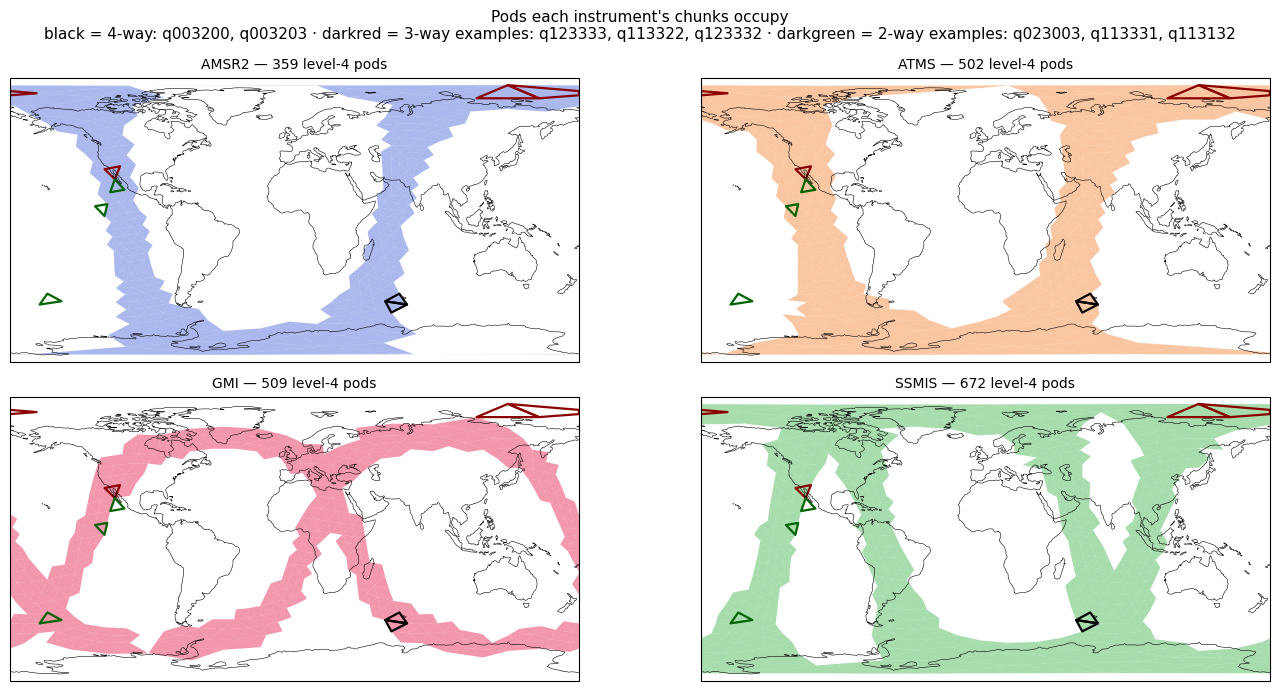

In [5]:
examples_by_width = {
    n_way: rendezvous_examples(events, n_way, count=wanted,
                               metadata=demo_meta, window=OVERLAP_DT)
    for n_way, wanted in [(2, 3), (3, 3), (4, 2)]
}
outlines = [
    (quad_pods, 'black', f'{widest}-way'),
    ([p for p, _, _ in examples_by_width[3]], 'darkred', '3-way examples'),
    ([p for p, _, _ in examples_by_width[2]], 'darkgreen', '2-way examples'),
]
fig = plot_pod_coverage(catalog, highlight=outlines)


## Part 4 — Rendezvous up close

A rendezvous must satisfy **both** criteria — same pod *and* same time
window — so each figure shows both: on the left, the data-element locations
(QL27 trixels) inside the pod; on the right, each instrument's overpass
interval on the time axis. First the closest 2-way rendezvous in the data —
GMI and SSMIS covering the same pod back to back — then the main attraction:
the pod where **all four** instruments meet within the 45-minute window — each drawn with the
window its case needs: Δt = 15 minutes is already enough for the tight pair,
and only the 4-way needs the full 45. An "instrument" in these
figures and tables merges **all** of that instrument's scan groups present in
the pod (`GMI_S1` + `GMI_S2` → GMI); the by-swath column shows the split.

Rendezvous here is performed at the **pod level** — a fast but broad way to
find overlaps between instruments' coverages. Once found, the STARE hierarchy
can be leveraged again to refine them to exact **data-element-level**
overlaps.


GT(_tbl_data=  instrument  data elements                                   by swath  \
0        GMI           9435                        S1: 4505 · S2: 4930   
1      SSMIS           8115  S1: 1325 · S2: 1327 · S3: 2775 · S4: 2688   

  pass start  pass end  
0   12:54:28  12:56:43  
1   12:56:53  12:59:36  , _body=<great_tables._gt_data.Body object at 0x1757691c0>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='data elements', type=<ColInfoTypeEnum.default: 1>, column_label='Data elements', column_align='right', column_width=None), ColInfo(var='by swath', type=<ColInfoTypeEnum.default: 1>, column_label='By swath', column_align='left', column_width=None), ColInfo(var='pass start', type=<ColInfoTypeEnum.default: 1>, column_label='Pass start', column_align='right', column_width=None), ColInfo(var='pass end', type=<ColInfoTypeEnum.default: 1>, column_label='Pass end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x17575dbe0>, _spanners=Spanners([]), _heading=Heading(title='Pod q023003 — a 2-way rendezvous', subtitle='instruments in order of arrival, all inside Δt = 15 min; the rendezvous completes 2025-01-01 12:56:53', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x17593a240>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175939700>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1759399d0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', 

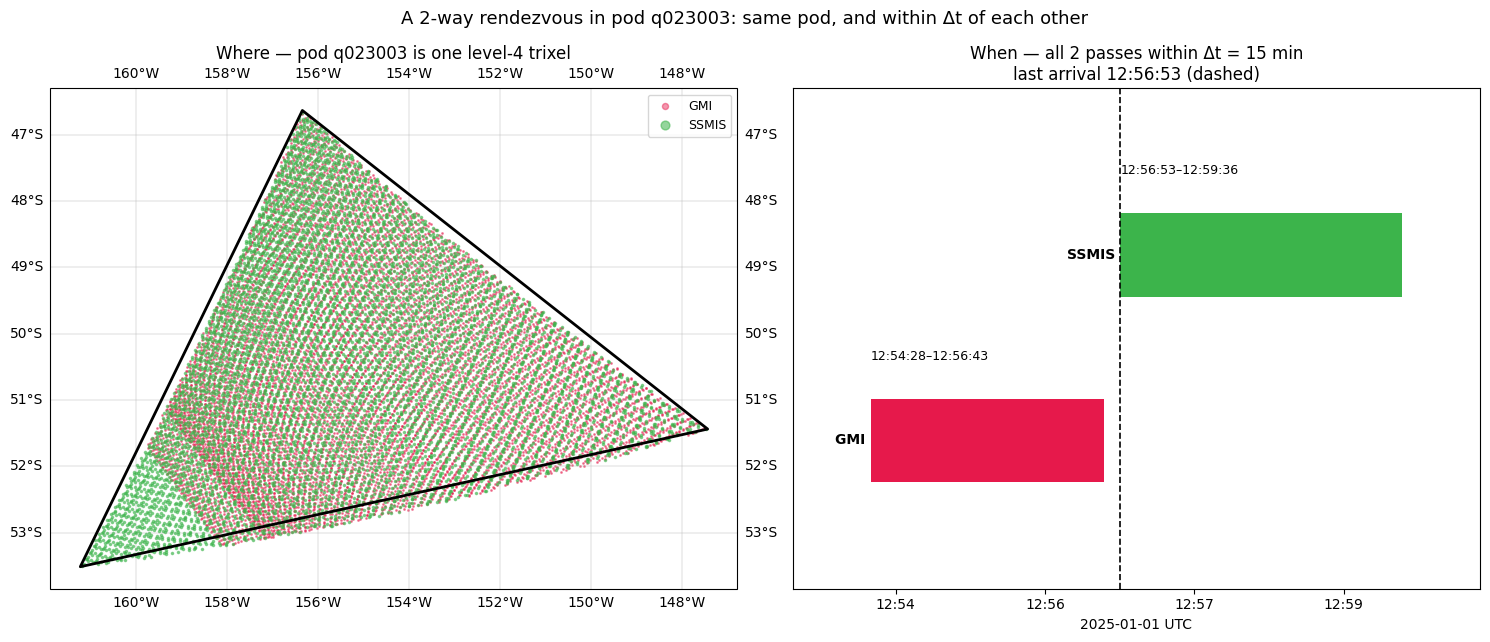

GT(_tbl_data=  instrument  data elements  \
0      SSMIS            439   
1      AMSR2           1102   
2       ATMS            284   
3        GMI           7139   

                                            by swath pass start  pass end  
0                S1: 92 · S2: 89 · S3: 108 · S4: 150   21:28:59  21:30:04  
1  S1: 159 · S2: 156 · S3: 155 · S4: 155 · S5: 29...   21:46:25  21:47:13  
2                                  S1: 143 · S2: 141   21:47:39  21:49:31  
3                                S1: 3776 · S2: 3363   22:13:52  22:16:30  , _body=<great_tables._gt_data.Body object at 0x175d28620>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='data elements', type=<ColInfoTypeEnum.default: 1>, column_label='Data elements', column_align='right', column_width=None), ColInfo(var='by swath', type=<ColInfoTypeEnum.default: 1>, column_label='By swath', column_align='left', column_width=None), ColInfo(var='pass start', type=<ColInfoTypeEnum.default: 1>, column_label='Pass start', column_align='right', column_width=None), ColInfo(var='pass end', type=<ColInfoTypeEnum.default: 1>, column_label='Pass end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175b3b4a0>, _spanners=Spanners([]), _heading=Heading(title='Pod q003200 — a 4-way rendezvous', subtitle='instruments in order of arrival, all inside Δt = 45 min; the rendezvous completes 2025-01-01 22:13:52', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175e05160>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175a54620>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175a56a80>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_

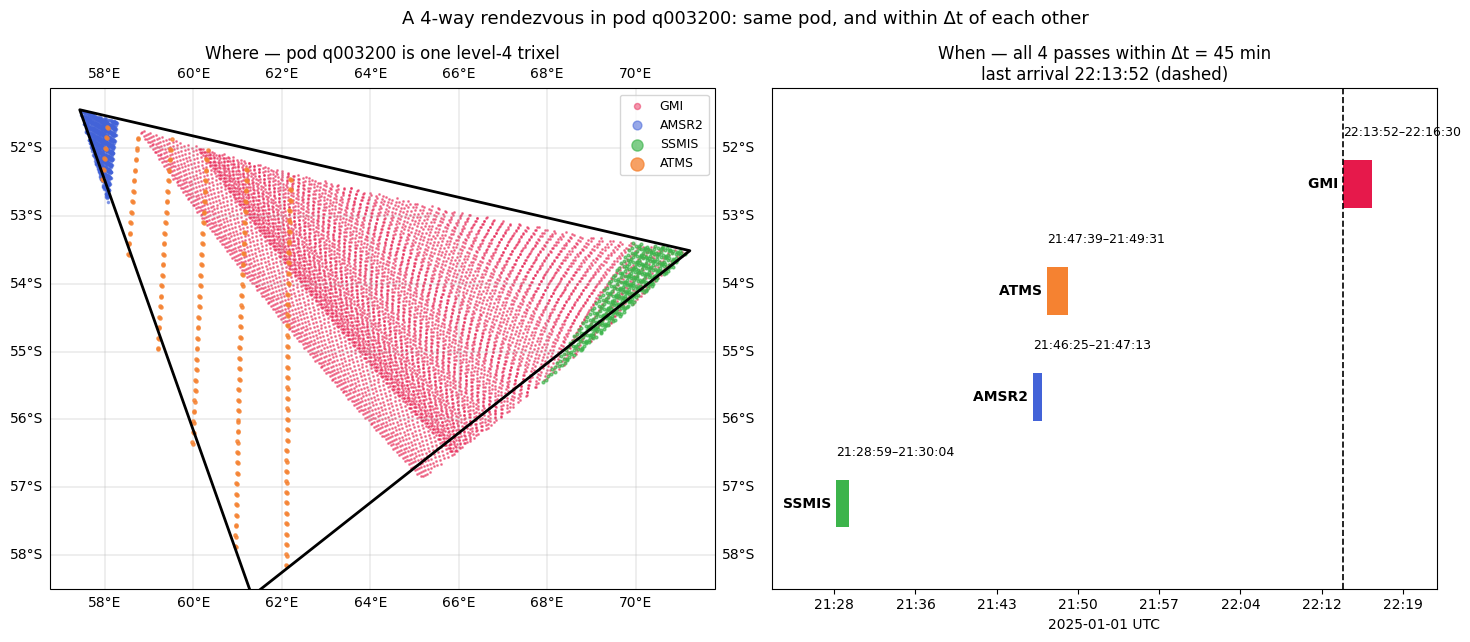

In [6]:
# Each case is drawn with the window its story needs: the GMI+SSMIS pair is
# so tight it already rendezvouses at the sweep's smallest window, 15 min --
# drawn at 45 min the two back-to-back passes would huddle at the edge of a
# mostly-empty 90-minute axis. Only the 4-way needs the full 45.
cases = [(examples_by_width[2][0], pd.Timedelta(minutes=15)),
         (examples_by_width[widest][0], OVERLAP_DT)]
for (pod, meeting, _), case_dt in cases:
    window = (meeting - case_dt, meeting + case_dt)
    # One download, kept per swath; the instrument view is the fold of it.
    swath_pixels = pod_pixels(demo, demo_meta, pod, window, fold=False)
    folded = {}
    for dataset, pixels in sorted(swath_pixels.items()):
        folded.setdefault(fold_instrument(dataset), []).append(pixels)
    passes = {inst: pd.concat(parts) for inst, parts in folded.items()}
    arrival = pd.DataFrame([
        {'instrument': instrument,
         'data elements': len(pixels),
         'by swath': ' · '.join(
             f"{ds.split('_', 1)[1]}: {len(px)}"
             for ds, px in sorted(swath_pixels.items())
             if fold_instrument(ds) == instrument),
         'pass start': pixels['timestamp'].min().strftime('%H:%M:%S'),
         'pass end': pixels['timestamp'].max().strftime('%H:%M:%S')}
        for instrument, pixels in sorted(passes.items(),
                                         key=lambda kv: kv[1]['timestamp'].min())
    ])
    display(
        GT(arrival)
        .tab_header(title=f"Pod {pod} — a {len(passes)}-way rendezvous",
                    subtitle="instruments in order of arrival, all inside "
                             f"Δt = {int(case_dt.total_seconds() // 60)} min; "
                             "the rendezvous completes "
                             f"{meeting.strftime('%Y-%m-%d %H:%M:%S')}")
    )
    fig = plot_rendezvous(pod, passes, meeting, case_dt)
    display(fig)
    plt.close(fig)


## Part 5 — Rendezvous over a region of interest

At last, a closer-to-the-real-world scenario: rendezvous over a
**user-defined region** in a **specified time window** — a spatial query for
the region against the pods, ANDed with a temporal query for the window. The
region of interest here is a bounding box covering the 4-way pod, first
converted into a STARE cover of trixels — STARE's adaptive resolution at
work; the window is the rendezvous itself, ± Δt. The contrast between the
criteria makes the AND visible: SSMIS also flew over this same region on a
*morning* orbit, outside the time window, and the period filter drops exactly
those chunks. Two figures illustrate it:
first the region itself — the bbox and the STARE cover it becomes — and,
after the counts, the *result*: the data elements the query returns (whole
chunks, pod-level granularity, so they extend past the bbox) beside every
spatially-selected chunk's time span, with the greyed-out morning pass far
outside the shaded window.


GT(_tbl_data=           criterion                                              value
0   Region (spatial)  bbox around pod q003200's trixel — lon [56.0, ...
1  Window (temporal)  2025-01-01 21:28:52 → 22:58:52 — the 4-way mee..., _body=<great_tables._gt_data.Body object at 0x175bc9400>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175a3d130>, _spanners=Spanners([]), _heading=Heading(title='The region-of-interest query', subtitle='a spatial criterion AND a temporal criterion', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1759812b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175983530>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175982330>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, ca

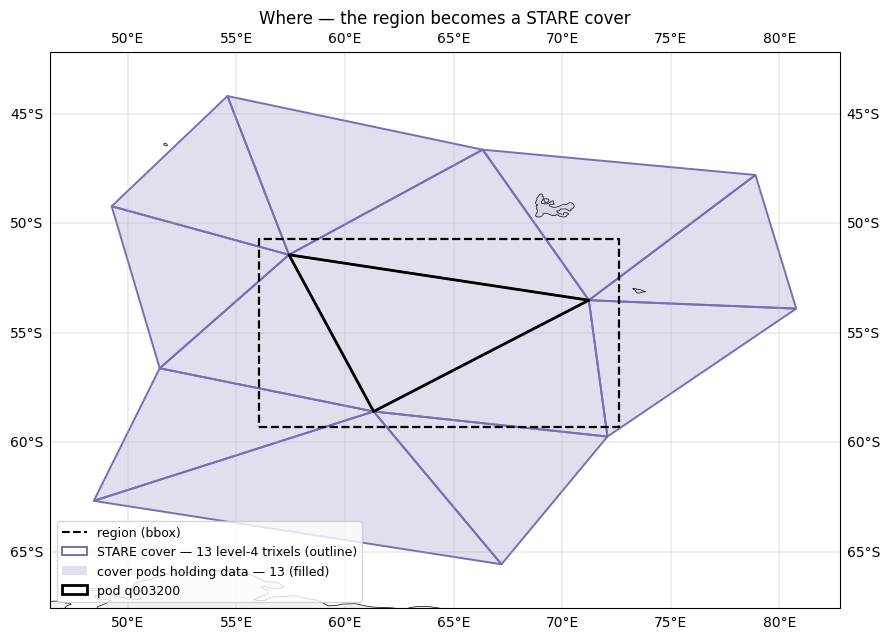

GT(_tbl_data=                                           criterion  chunks
0  Temporal only — whole demo footprint in the wi...    1478
1        Spatial only — this region, any time of day     154
2                               Spatial AND temporal     116, _body=<great_tables._gt_data.Body object at 0x175ddc050>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='Criterion', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x175ddf290>, _spanners=Spanners([]), _heading=Heading(title='One query, both filters', subtitle='the spatial-only surplus is the SSMIS morning pass over the same region', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175c476e0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175c454c0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175c44f50>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px'

GT(_tbl_data=  instrument  spatial_only  both_filters          first_start  \
0      AMSR2            48            48  2025-01-01 21:43:37   
1       ATMS            20            20  2025-01-01 21:45:33   
2        GMI            18            18  2025-01-01 22:11:52   
3      SSMIS            68            30  2025-01-01 21:26:18   

              last_end  
0  2025-01-01 21:50:23  
1  2025-01-01 21:51:31  
2  2025-01-01 22:17:43  
3  2025-01-01 21:33:04  , _body=<great_tables._gt_data.Body object at 0x175686150>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='spatial_only', type=<ColInfoTypeEnum.default: 1>, column_label='Spatial only', column_align='right', column_width=None), ColInfo(var='both_filters', type=<ColInfoTypeEnum.default: 1>, column_label='Both filters', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x17536fa70>, _spanners=Spanners([]), _heading=Heading(title='Surviving chunks by instrument', subtitle='in 13 pod(s), among them the 4-way pod q003200, q003203', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x175065a90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x175065ac0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x175066300>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True

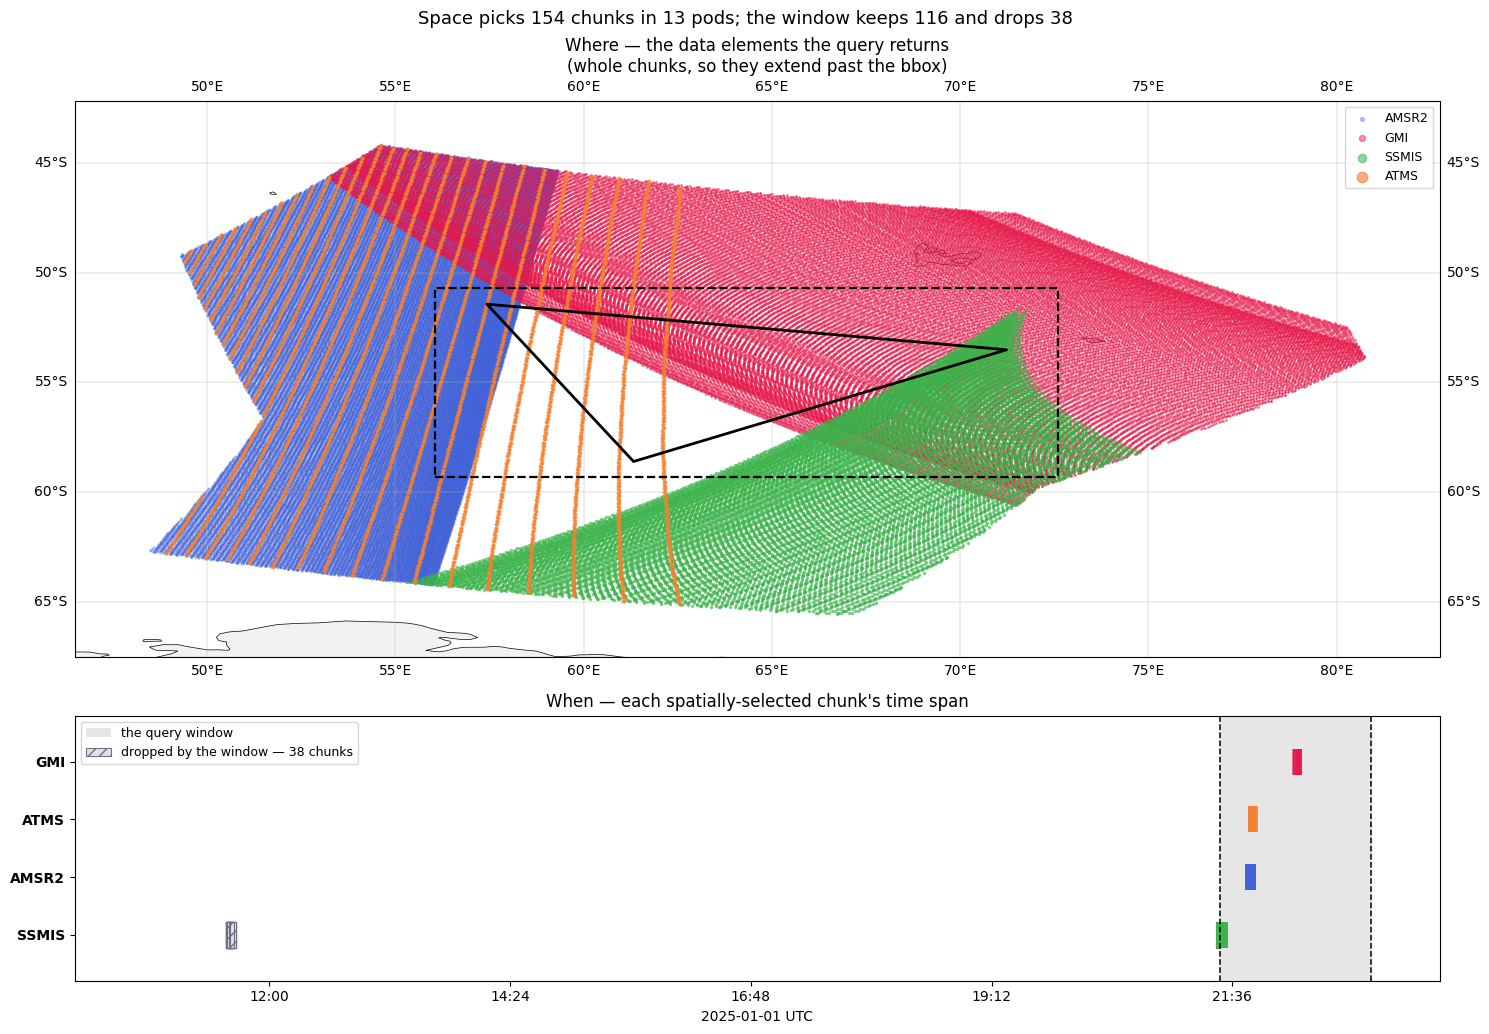

In [7]:
pod, meeting, _ = examples_by_width[widest][0]
lon_min, lat_min, lon_max, lat_max = pod_trixels([pod]).total_bounds
# Pad the box ~10% so it holds the trixel with a margin instead of cutting
# its corners — the largest pad whose level-4 cover is still the same 13
# trixels, so every count below is unchanged.
pad_lon, pad_lat = (lon_max - lon_min) * 0.10, (lat_max - lat_min) * 0.10
lon_min, lon_max = lon_min - pad_lon, lon_max + pad_lon
lat_min, lat_max = lat_min - pad_lat, lat_max + pad_lat
location_sids = demo.get_sids_for_bbox(lon_min, lat_min, lon_max, lat_max,
                                       level=STARE_LEVEL)
window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
query = pd.DataFrame([
    {'criterion': 'Region (spatial)',
     'value': f"bbox around pod {pod}'s trixel — "
              f"lon [{lon_min:.1f}, {lon_max:.1f}], "
              f"lat [{lat_min:.1f}, {lat_max:.1f}] "
              f"→ {len(location_sids)} level-{STARE_LEVEL} cover SIDs"},
    {'criterion': 'Window (temporal)',
     'value': f"{window[0].strftime('%Y-%m-%d %H:%M:%S')} → "
              f"{window[1].strftime('%H:%M:%S')} "
              f"— the {widest}-way meeting ± Δt"},
])
display(
    GT(query)
    .tab_header(title="The region-of-interest query",
                subtitle="a spatial criterion AND a temporal criterion")
    .cols_label(criterion="", value="")
)

spatial_only = demo.find_intersecting_data(location_sids, INSTRUMENTS,
                                           path_prefix=S3_PREFIX)
fig = plot_region_cover((lon_min, lat_min, lon_max, lat_max), location_sids,
                        spatial_only, highlight_pod=pod)
display(fig)
plt.close(fig)

temporal_only = load_s3_metadata(period=window, path_prefix=S3_PREFIX)
both = demo.find_intersecting_data(location_sids, INSTRUMENTS, period=window,
                                   path_prefix=S3_PREFIX)
criteria = pd.DataFrame([
    {'criterion': 'Temporal only — whole demo footprint in the window',
     'chunks': len(temporal_only)},
    {'criterion': 'Spatial only — this region, any time of day',
     'chunks': len(spatial_only)},
    {'criterion': 'Spatial AND temporal', 'chunks': len(both)},
])
display(
    GT(criteria)
    .tab_header(title="One query, both filters",
                subtitle="the spatial-only surplus is the SSMIS morning pass "
                         "over the same region")
)

per_instrument = (
    both.assign(instrument=both['Dataset'].map(fold_instrument))
        .groupby('instrument')
        .agg(both_filters=('podcode', 'size'),
             first_start=('t_start', 'min'),
             last_end=('t_end', 'max'))
)
per_instrument.insert(0, 'spatial_only', (
    spatial_only.assign(instrument=spatial_only['Dataset'].map(fold_instrument))
    .groupby('instrument').size()
))
display(
    GT(fmt_times(per_instrument.reset_index(), ('first_start', 'last_end')))
    .tab_header(title="Surviving chunks by instrument",
                subtitle=f"in {both['podcode'].nunique()} pod(s), among them "
                         f"the {widest}-way pod "
                         + ', '.join(sorted(p for p in both['podcode'].unique()
                                            if p in quad_pods)))
    .cols_label(spatial_only="Spatial only", both_filters="Both filters",
                first_start="First t_start", last_end="Last t_end")
)

region_passes = chunk_pixels(demo, both, window)   # the 116 surviving chunks
fig = plot_region_result(region_passes, spatial_only, window,
                         bbox=(lon_min, lat_min, lon_max, lat_max),
                         highlight_pod=pod)
display(fig)
plt.close(fig)


## Recap

In this video we demonstrated a construction of the STARE Parallel Optimized
Data Store, **STARE-PODS**. During the construction, a DBMS is used to
catalog the relevant metadata, and it supports **pod-level rendezvous
analytics** — often the first step in the integrative analysis of diverse
data. These rendezvous can be efficiently refined by leveraging the STARE
hierarchy to obtain data-element-level rendezvous.

Since the Parquet chunks' file names contain the pod codes, and their
contents the spatiotemporal information of the data, rendezvous analytics can
also be performed using the Parquet chunks alone — less efficiently than with
the database, but still better than the existing way.
